# **OPTIMIZING ALGORITHMS**
Deep learning models learn by minimizing a loss function through iterative updates of their parameters. The algorithm responsible for performing these updates is known as an optimizer. Different optimization algorithms can significantly affect the speed of convergence, training stability, and final model performance.

In this project, a Convolutional Neural Network (CNN) is trained on the CIFAR-10 dataset using various optimization algorithms, including SGD, Momentum, RMSProp, and Adam. The impact of Learning Rate Decay is also evaluated. By comparing validation accuracy and loss across these methods, this project aims to understand how different optimization techniques influence the training process and overall model performance.



In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D

In [ ]:
from tensorflow.keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
model = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

## **Stochastic Gradient Descent (SGD)** <br>
Neural networks learn by minimizing a loss function. The simplest approach is Gradient Descent, where the model updates its weights in the direction that reduces the loss. SGD provides an efficient way to perform these updates using mini-batches of data rather than the entire dataset.<br>

### **Mathematical Intuition**<br>
Imagine standing on a mountain and trying to reach the lowest point. The gradient tells you which direction is uphill, so you move in the opposite direction. SGD repeatedly takes small steps downhill until it reaches a minimum.

**Key Formula**

w:=w−α∇J(w)

where:

w = model parameters (weights) <br>
α = learning rate <br>
∇J(w) = gradient of the loss function


In [ ]:
model.compile(
    optimizer= tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_sgd= model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.1890 - loss: 2.2313 - val_accuracy: 0.2666 - val_loss: 2.0982
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 183ms/step - accuracy: 0.2789 - loss: 2.0102 - val_accuracy: 0.2765 - val_loss: 2.0130
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.3230 - loss: 1.9087 - val_accuracy: 0.2875 - val_loss: 1.9500
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.3592 - loss: 1.8149 - val_accuracy: 0.3299 - val_loss: 1.8469
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.3951 - loss: 1.7173 - val_accuracy: 0.4102 - val_loss: 1.6718
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 185ms/step - accuracy: 0.4219 - loss: 1.6350 - val_accuracy: 0.4244 - val_loss: 1.6203
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 184ms/step - accuracy: 0.4458 - loss: 1.5597 - val_accuracy: 0.4401 - val_loss: 1.5564
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 183ms/step - accuracy: 0.4661 - loss: 1

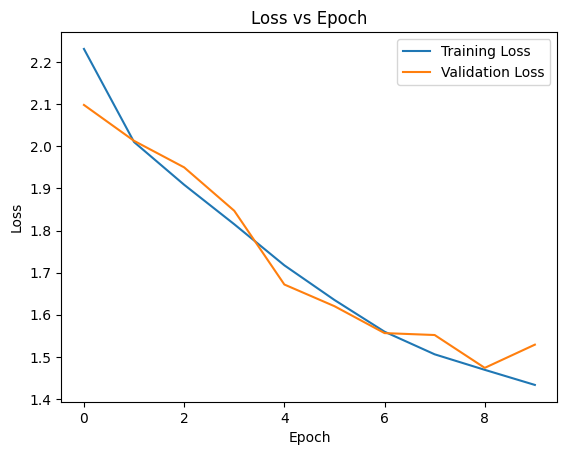

In [ ]:
plt.plot(history_sgd.history['loss'], label='Training Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

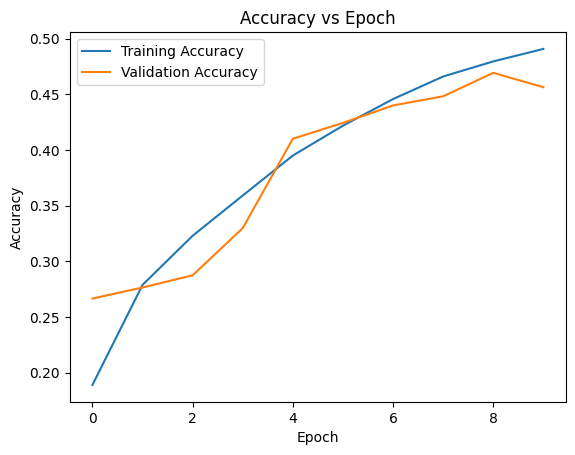

In [ ]:
plt.plot(history_sgd.history['accuracy'], label='Training Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

## **Momentum**
SGD often zig-zags while moving toward the minimum, especially when the loss surface contains steep slopes in some directions and shallow slopes in others. Momentum helps accelerate convergence by remembering previous updates.

### **Mathematical Intuition**
Think of a ball rolling downhill. Instead of stopping and recalculating its direction after every step, it gains velocity and continues moving in the same general direction. This reduces oscillations and speeds up learning.

### **Key Formula**

Velocity update: <br>
v_t = βv_(t-1) + (1-β)∇J(w_t)

Weight update: <br>
w := w - αv_t

where <br>
v_t = velocity <br>
β = momentum coefficient<br>
α = learning rate

In [ ]:
model.compile(
    optimizer= tf.keras.optimizers.SGD(learning_rate=0.01, momentum = 0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_momentum= model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 176ms/step - accuracy: 0.4910 - loss: 1.4215 - val_accuracy: 0.5204 - val_loss: 1.3679
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 180ms/step - accuracy: 0.5567 - loss: 1.2507 - val_accuracy: 0.5707 - val_loss: 1.2246
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.6039 - loss: 1.1313 - val_accuracy: 0.5867 - val_loss: 1.1803
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.6371 - loss: 1.0376 - val_accuracy: 0.6311 - val_loss: 1.0689
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 174ms/step - accuracy: 0.6629 - loss: 0.9642 - val_accuracy: 0.6315 - val_loss: 1.0602
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 178ms/step - accuracy: 0.6927 - loss: 0.8855 - val_accuracy: 0.6553 - val_loss: 1.0001
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 172ms/step - accuracy: 0.7130 - loss: 0.8270 - val_accuracy: 0.6508 - val_loss: 1.0286
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.7348 - loss: 0

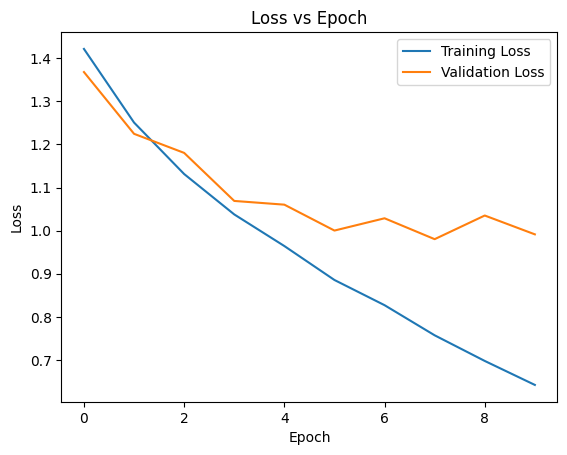

In [ ]:
plt.plot(history_momentum.history['loss'], label='Training Loss')
plt.plot(history_momentum.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

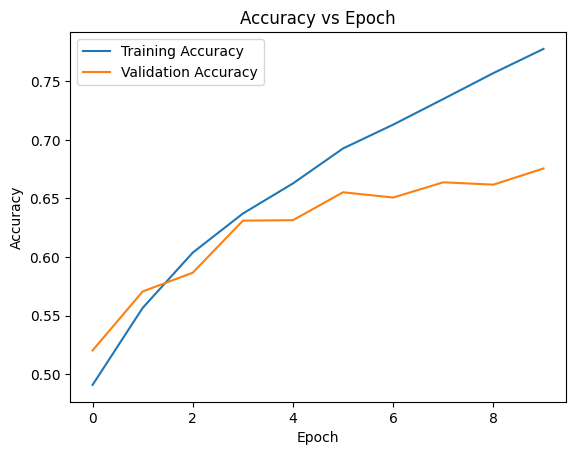

In [ ]:
plt.plot(history_momentum.history['accuracy'], label='Training Accuracy')
plt.plot(history_momentum.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

## **RMSProp**
Different parameters may require different learning rates. SGD and Momentum use the same learning rate for all parameters, which can slow learning. RMSProp adapts the learning rate individually for each parameter.
### **Mathematical Intuition**
Parameters receiving large gradients should take smaller steps, while parameters receiving small gradients should take larger steps. RMSProp accomplishes this by maintaining an exponentially weighted average of squared gradients.

### **Key Formula**

Running average of squared gradients: <br>
s_t = βs_(t-1) + (1-β)(∇J(w_t))²

Parameter update:<br>
w := w - α * (∇J(w) / (√s_t + ε))

where:<br>
s_t = exponentially weighted average of squared gradients <br>
ε = small constant to avoid division by zero


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_rmsprop= model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 176ms/step - accuracy: 0.7355 - loss: 0.7627 - val_accuracy: 0.6629 - val_loss: 1.0176
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.7791 - loss: 0.6349 - val_accuracy: 0.6457 - val_loss: 1.1552
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 181ms/step - accuracy: 0.8144 - loss: 0.5337 - val_accuracy: 0.6818 - val_loss: 1.0438
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.8489 - loss: 0.4408 - val_accuracy: 0.6850 - val_loss: 1.0721
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 187ms/step - accuracy: 0.8730 - loss: 0.3682 - val_accuracy: 0.6727 - val_loss: 1.1510
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 175ms/step - accuracy: 0.8981 - loss: 0.2999 - val_accuracy: 0.6939 - val_loss: 1.1564
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - accuracy: 0.9187 - loss: 0.2412 - val_accuracy: 0.6973 - val_loss: 1.1962
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.9362 - loss: 0

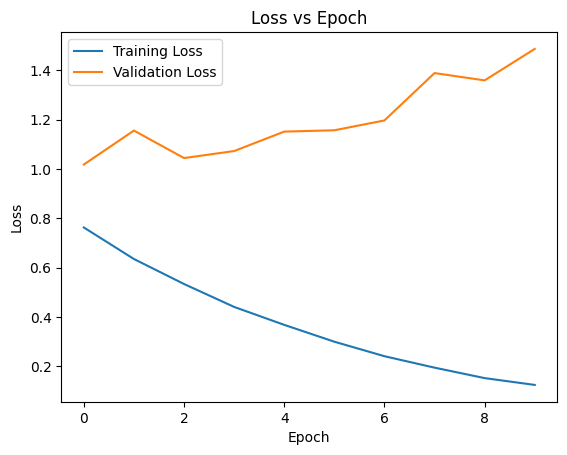

In [ ]:
plt.plot(history_rmsprop.history['loss'], label='Training Loss')
plt.plot(history_rmsprop.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

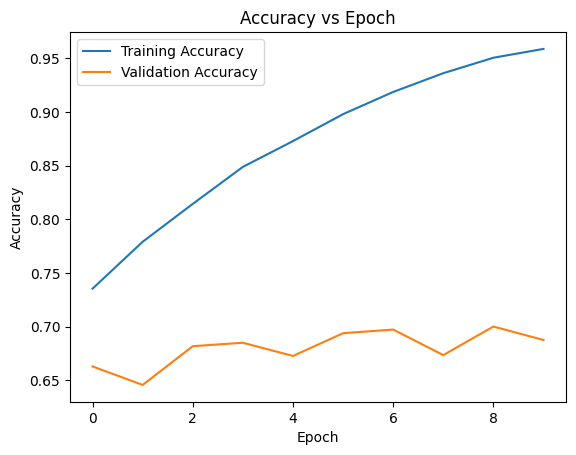

In [ ]:
plt.plot(history_rmsprop.history['accuracy'], label='Training Accuracy')
plt.plot(history_rmsprop.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

## **Adam (Adaptive Moment Estimation)**
Adam combines the strengths of Momentum and RMSProp. It uses both gradient history and squared gradient history to achieve faster and more stable convergence.

### **Mathematical Intuition**

Momentum keeps track of the direction of past gradients, while RMSProp adapts learning rates. Adam combines both ideas, making it one of the most widely used optimization algorithms in deep learning.

### **Key Formula**

First moment estimate: <br>
m_t = β₁m_(t-1) + (1-β₁)∇J(w_t) <br>

Second moment estimate:<br>
v_t = β₂v_(t-1) + (1-β₂)(∇J(w_t))²

Parameter update:<br>
w := w - α * (m_t / (√v_t + ε))

where:<br>
m_t = first moment estimate <br>
v_t = second moment estimate <br>
β₁ ≈ 0.9 <br>
β₂ ≈ 0.999

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 182ms/step - accuracy: 0.9668 - loss: 0.1015 - val_accuracy: 0.6841 - val_loss: 1.5218
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.9744 - loss: 0.0839 - val_accuracy: 0.6887 - val_loss: 1.6426
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.9776 - loss: 0.0736 - val_accuracy: 0.6811 - val_loss: 1.7495
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 172ms/step - accuracy: 0.9826 - loss: 0.0577 - val_accuracy: 0.6870 - val_loss: 1.8349
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 180ms/step - accuracy: 0.9790 - loss: 0.0653 - val_accuracy: 0.6859 - val_loss: 1.8828
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.9868 - loss: 0.0458 - val_accuracy: 0.6812 - val_loss: 1.9449
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 174ms/step - accuracy: 0.9832 - loss: 0.0498 - val_accuracy: 0.6873 - val_loss: 2.0028
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 173ms/step - accuracy: 0.9862 - loss: 0

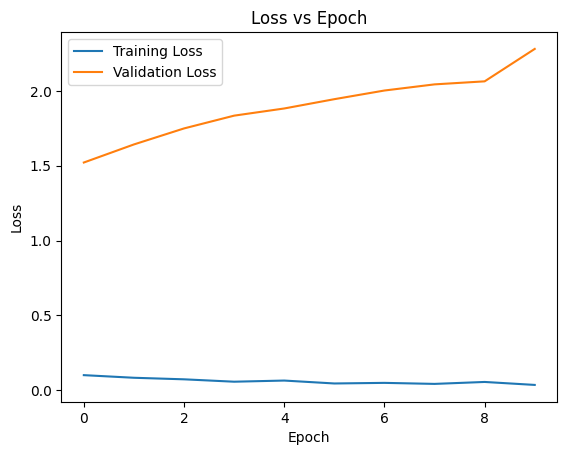

In [ ]:
plt.plot(history_adam.history['loss'], label='Training Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

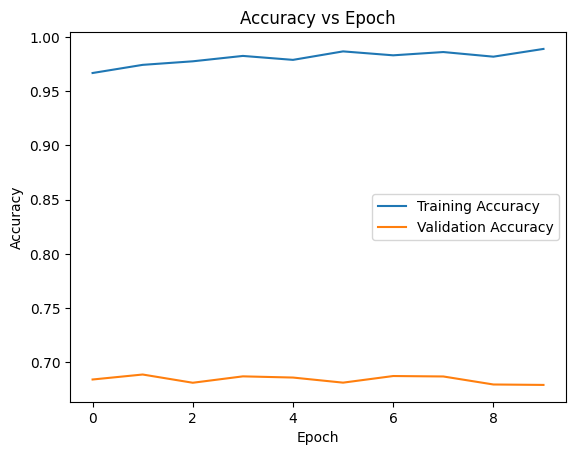

In [ ]:
plt.plot(history_adam.history['accuracy'], label='Training Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

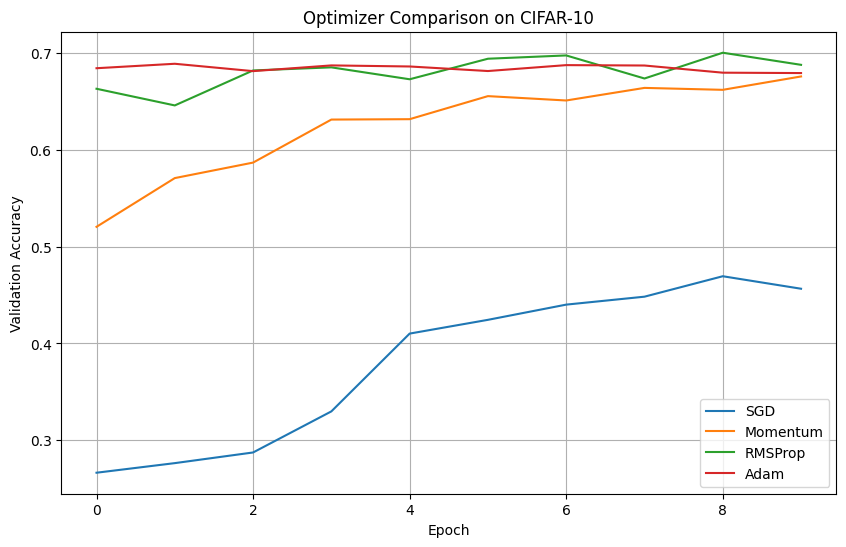

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    history_sgd.history['val_accuracy'],
    label='SGD'
)

plt.plot(
    history_momentum.history['val_accuracy'],
    label='Momentum'
)

plt.plot(
    history_rmsprop.history['val_accuracy'],
    label='RMSProp'
)

plt.plot(
    history_adam.history['val_accuracy'],
    label='Adam'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Optimizer Comparison on CIFAR-10')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("SGD:", max(history_sgd.history['val_accuracy']))
print("Momentum:", max(history_momentum.history['val_accuracy']))
print("RMSProp:", max(history_rmsprop.history['val_accuracy']))
print("Adam:", max(history_adam.history['val_accuracy']))

SGD: 0.46939998865127563
Momentum: 0.675599992275238
RMSProp: 0.7001000046730042
Adam: 0.6887000203132629


## **Conclusion**

In this project, the performance of four optimization algorithms—SGD, Momentum, RMSProp, and Adam—was evaluated on the CIFAR-10 image classification task using the same CNN architecture. The results showed that the choice of optimizer has a significant impact on training speed and model performance.

SGD exhibited the slowest convergence and achieved the lowest validation accuracy. Adding Momentum substantially improved convergence by reducing oscillations and accelerating learning. RMSProp and Adam achieved the highest validation accuracies and converged much faster than SGD and Momentum. Among all the optimizers tested, RMSProp and Adam demonstrated the best overall performance in terms of convergence speed and final accuracy.

However, the training and validation curves also suggested that RMSProp and Adam were more prone to overfitting. Both optimizers continued to improve training performance while validation performance began to plateau, indicating that the models were starting to fit the training data more closely than the unseen validation data. In contrast, SGD and Momentum showed slower learning and less pronounced signs of overfitting, although they achieved lower overall accuracy.

These experiments highlight the importance of optimization algorithms in deep learning and provide practical insight into how different approaches affect the training process. While adaptive optimization methods such as RMSProp and Adam can achieve superior performance, they may also increase the risk of overfitting, emphasizing the need for appropriate regularization techniques when training deep neural networks.
